In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import streamlit as st
import joblib as jb

## Load Data

In [40]:
data = pd.read_csv("Telco-Customer-Churn.csv")
df = pd.DataFrame(data)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## EDA

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [42]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [43]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

<Axes: >

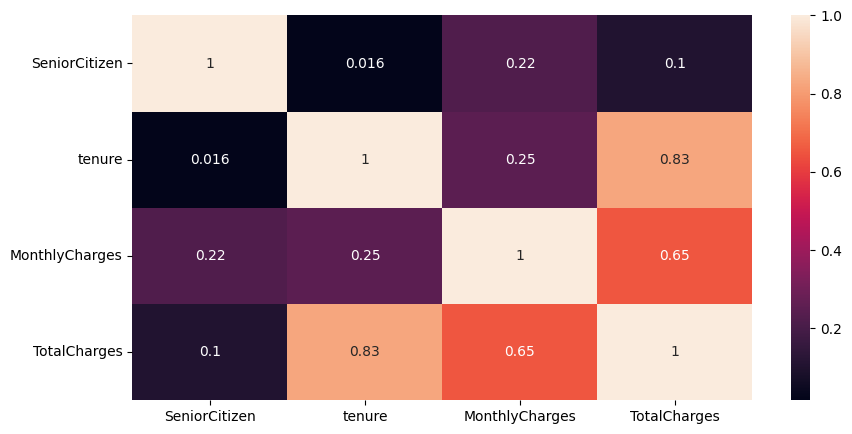

In [46]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df_numeric = df.drop('customerID', axis=1).select_dtypes(include=np.number)
plt.figure(figsize=(10,5))
sns.heatmap(df_numeric.corr(), annot=True)

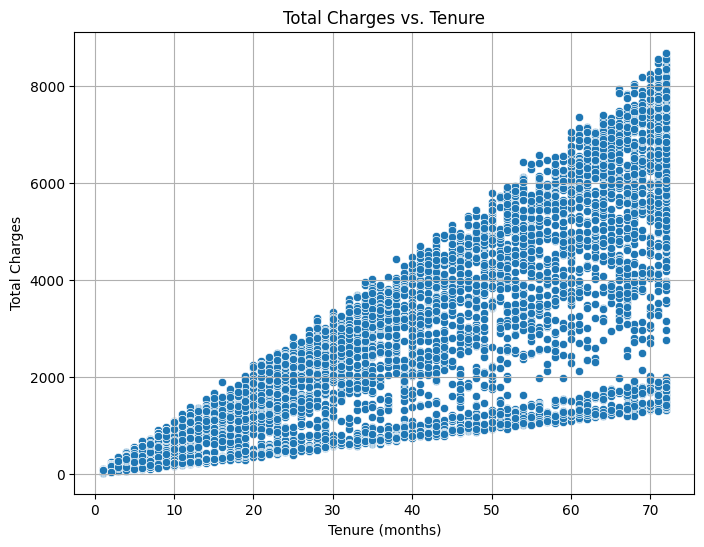

In [47]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='tenure', y='TotalCharges', data=df)
plt.title('Total Charges vs. Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Total Charges')
plt.grid(True)
plt.show()

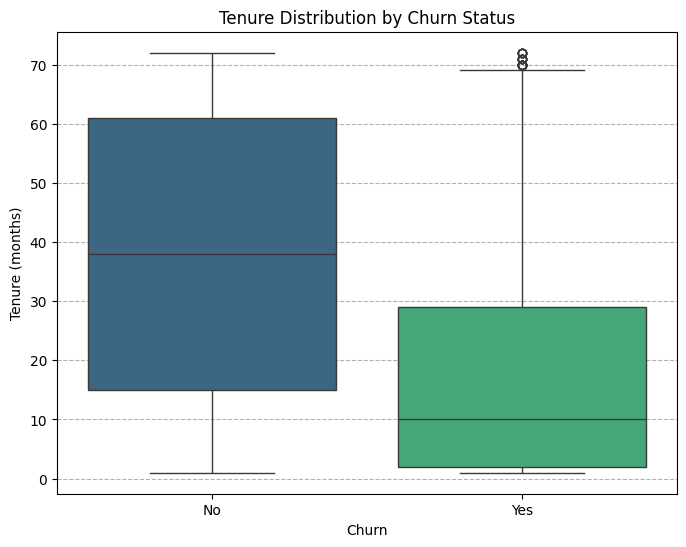

In [48]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.grid(axis='y', linestyle='--', alpha=1.0)
plt.show()

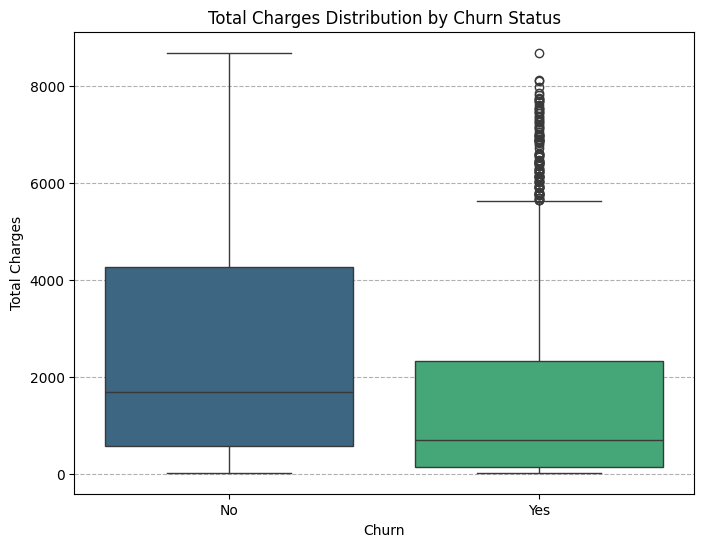

In [49]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='TotalCharges', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Total Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
plt.grid(axis='y', linestyle='--', alpha=1.0)
plt.show()

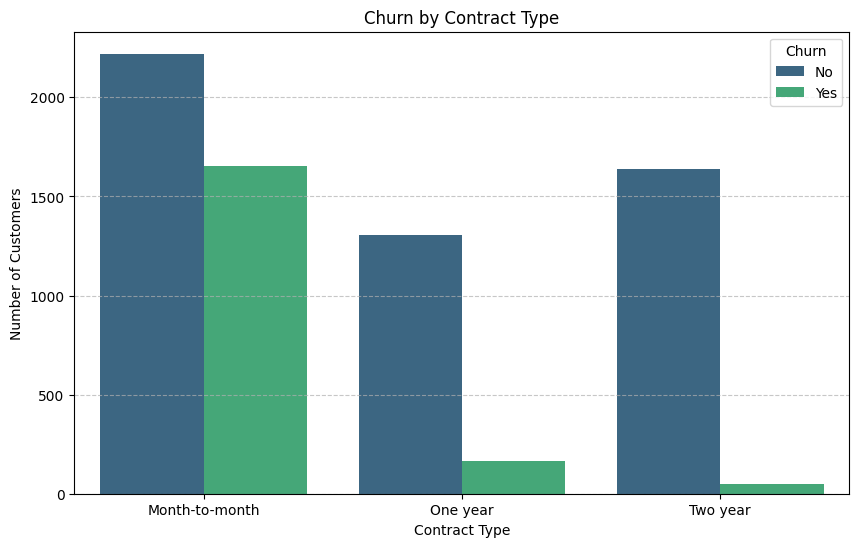

In [50]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Data Preprocessing

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [52]:
df_numeric = df.drop('customerID', axis=1).select_dtypes(include=np.number)
df_numeric.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [53]:
df_category = df.drop('customerID', axis=1).select_dtypes(exclude=np.number)
df_category.columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [68]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df_category.columns:
  df_category[col] = le.fit_transform(df_category[col])
df_category = df_category.reset_index(drop=True)
df_category.tail()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
7027,1,1,1,1,2,0,2,0,2,2,2,2,1,1,3,0
7028,0,1,1,1,2,1,0,2,2,0,2,2,1,1,1,0
7029,0,1,1,0,1,0,2,0,0,0,0,0,0,1,2,0
7030,1,1,0,1,2,1,0,0,0,0,0,0,0,1,3,1
7031,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0


In [56]:
numeric_cols = df_numeric.columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_numeric = scaler.fit_transform(df_numeric)
df_numeric = pd.DataFrame(df_numeric, columns=numeric_cols)
df_numeric.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,-0.440327,-1.280248,-1.161694,-0.994194
1,-0.440327,0.064303,-0.260878,-0.173740
2,-0.440327,-1.239504,-0.363923,-0.959649
3,-0.440327,0.512486,-0.747850,-0.195248
4,-0.440327,-1.239504,0.196178,-0.940457


In [69]:
df = pd.concat([df_category, df_numeric], axis=1)
df.head()

target = df['Churn']
features = df.drop('Churn', axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
y_train.value_counts()

,count
Churn,
0,4130
1,1495


In [58]:
target = df['Churn']
features = df.drop('Churn', axis=1)

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
y_train.value_counts()

,count
Churn,
0.0,4119
1.0,1507


In [64]:
# Model Selection
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [72]:
# Decison Tree Classifier
Decison_Model = DecisionTreeClassifier()
Decison_Model.fit(X_train, y_train)

DecisionTreeClassifier()

In [73]:
Decison_Model.score(X_test, y_test)

0.728500355366027

In [74]:
# Random Forest Classifier
RandomForest_Model = RandomForestClassifier()
RandomForest_Model.fit(X_train, y_train)

RandomForestClassifier()

In [75]:
RandomForest_Model.score(X_test, y_test)

0.7889125799573561

In [76]:
# Logistic Regression
Logistic_Model = LogisticRegression()
Logistic_Model.fit(X_train, y_train)

LogisticRegression()

In [77]:
Logistic_Model.score(X_test, y_test)

0.7860696517412935

In [78]:
# Support Vector Classifier
SVC_Model = SVC()
SVC_Model.fit(X_train, y_train)

SVC()

In [79]:
SVC_Model.score(X_test, y_test)

0.7931769722814499

In [81]:
import joblib
joblib.dump(RandomForest_Model, 'random_forest_model.joblib')
print("RandomForest_Model saved successfully.")

RandomForest_Model saved successfully.


In [82]:
loaded_rf_model = joblib.load('random_forest_model.joblib')
print("RandomForest_Model loaded successfully.")
print(f"Type of loaded model: {type(loaded_rf_model)}")

RandomForest_Model loaded successfully.
Type of loaded model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


## Summary:

### Q&A
Yes, the model has been successfully saved. To load it back into memory, you can use the `joblib.load()` function, specifying the filename where the model was saved. For example: `loaded_model = joblib.load('random_forest_model.joblib')`.

### Data Analysis Key Findings
*   The `RandomForest_Model` was successfully saved to a file named `random_forest_model.joblib`.
*   The model was subsequently loaded back into memory without issues, confirming the saving process's success.
*   The type of the loaded model was confirmed to be `<class 'sklearn.ensemble._forest.RandomForestClassifier'>`, indicating that the model's structure and contents were preserved during the save and load operations.

### Insights or Next Steps
*   The successfully saved model can now be easily deployed or used for future predictions without requiring retraining.
*   The loaded model can be directly used to make predictions on new data, for example, by calling `loaded_rf_model.predict(new_data)`.
